In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/crime_dataset_india.csv")

ncr_cities = ["Delhi", "Ghaziabad", "Faridabad"]

df = df[df["City"].isin(ncr_cities)].copy()

df["Weapon Used"] = df["Weapon Used"].fillna("Unknown")

df["Date Reported"] = pd.to_datetime(
    df["Date Reported"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

df["Date of Occurrence"] = pd.to_datetime(
    df["Date of Occurrence"],
    format="%m-%d-%Y %H:%M",
    errors="coerce"
)

df["Time of Occurrence"] = pd.to_datetime(
    df["Time of Occurrence"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

df["Date Case Closed"] = pd.to_datetime(
    df["Date Case Closed"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

In [3]:
df["Year"] = df["Date of Occurrence"].dt.year
df["Month"] = df["Date of Occurrence"].dt.month
df["MonthName"] = df["Date of Occurrence"].dt.month_name()

df["Day"] = df["Date of Occurrence"].dt.day

df["DayOfWeek"] = df["Date of Occurrence"].dt.day_name()

df["Hour"] = df["Date of Occurrence"].dt.hour

In [4]:
df["IsWeekend"] = df["DayOfWeek"].isin(
    ["Saturday", "Sunday"]
)

In [5]:
df["IsNightCrime"] = (
    (df["Hour"] >= 20) |
    (df["Hour"] <= 5)
)

In [6]:
bins = [0, 18, 30, 45, 60, 100]

labels = [
    "Child",
    "Young Adult",
    "Adult",
    "Middle Age",
    "Senior"
]

df["VictimAgeGroup"] = pd.cut(
    df["Victim Age"],
    bins=bins,
    labels=labels
)

In [7]:
df["IsCaseClosed"] = (
    df["Case Closed"]
    .str.upper()
    .eq("YES")
)

In [8]:
df["CaseResolutionDays"] = (
    df["Date Case Closed"] -
    df["Date Reported"]
).dt.days

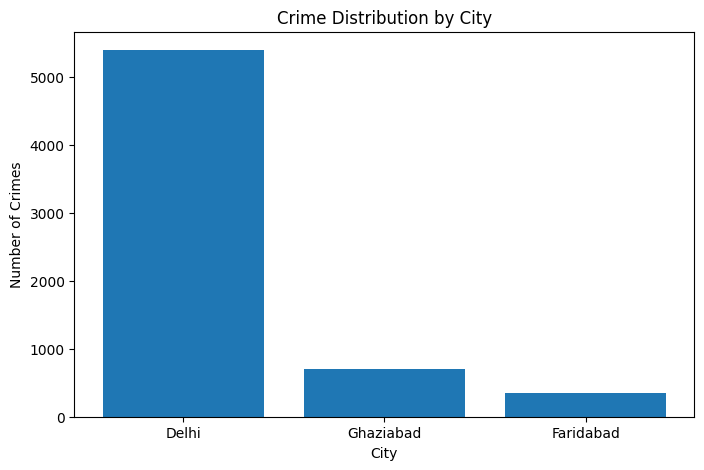

In [9]:
city_counts = df["City"].value_counts()

plt.figure(figsize=(8,5))
plt.bar(city_counts.index, city_counts.values)

plt.title("Crime Distribution by City")
plt.xlabel("City")
plt.ylabel("Number of Crimes")

plt.show()

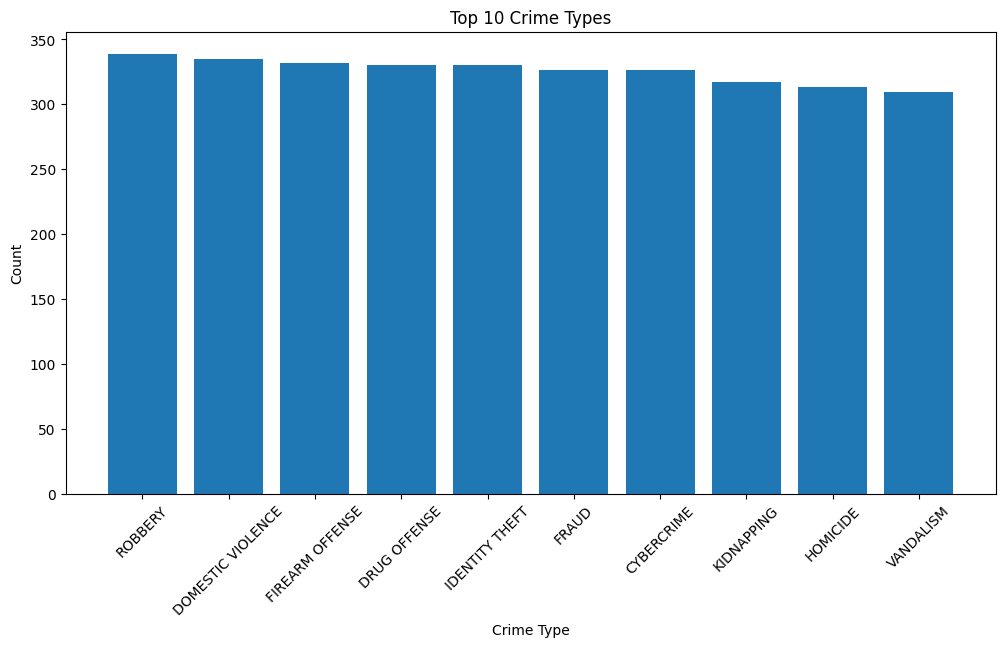

In [10]:
crime_counts = df["Crime Description"].value_counts().head(10)

plt.figure(figsize=(12,6))
plt.bar(crime_counts.index, crime_counts.values)

plt.xticks(rotation=45)

plt.title("Top 10 Crime Types")
plt.xlabel("Crime Type")
plt.ylabel("Count")

plt.show()

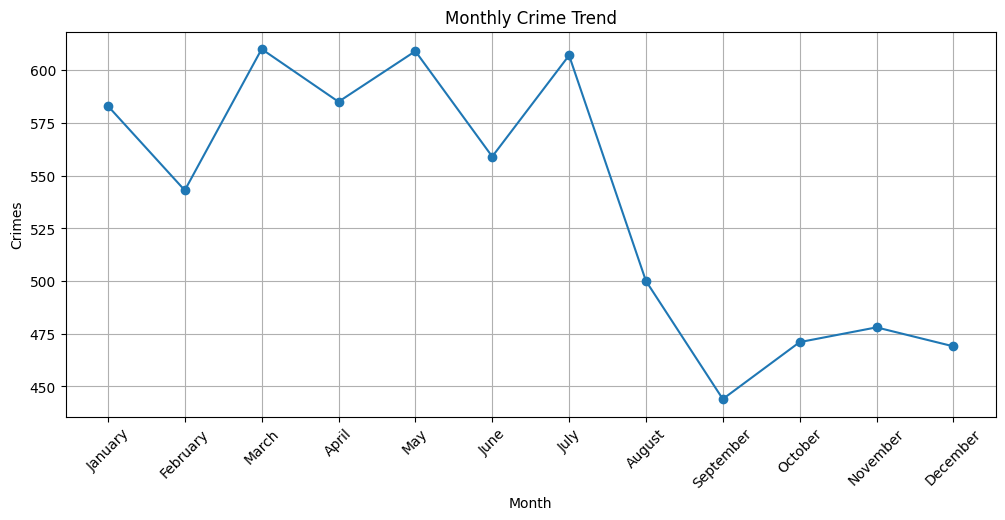

In [11]:
month_counts = (
    df.groupby("MonthName")
      .size()
      .reindex([
          "January","February","March","April","May","June",
          "July","August","September","October","November","December"
      ])
)

plt.figure(figsize=(12,5))

plt.plot(month_counts.index, month_counts.values, marker="o")

plt.xticks(rotation=45)

plt.title("Monthly Crime Trend")
plt.xlabel("Month")
plt.ylabel("Crimes")

plt.grid()

plt.show()

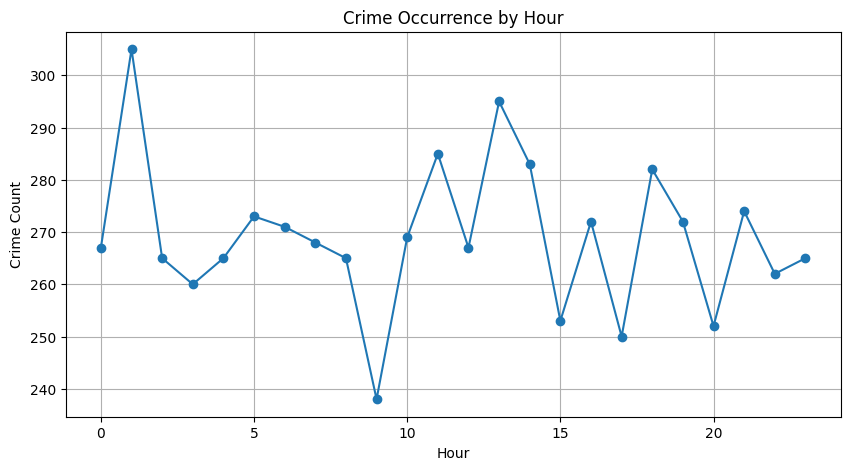

In [12]:
hour_counts = df["Hour"].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.plot(hour_counts.index, hour_counts.values, marker="o")

plt.title("Crime Occurrence by Hour")

plt.xlabel("Hour")

plt.ylabel("Crime Count")

plt.grid()

plt.show()

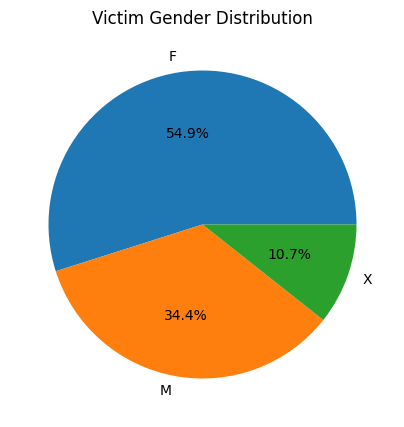

In [13]:
gender = df["Victim Gender"].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    gender.values,
    labels=gender.index,
    autopct="%1.1f%%"
)

plt.title("Victim Gender Distribution")

plt.show()

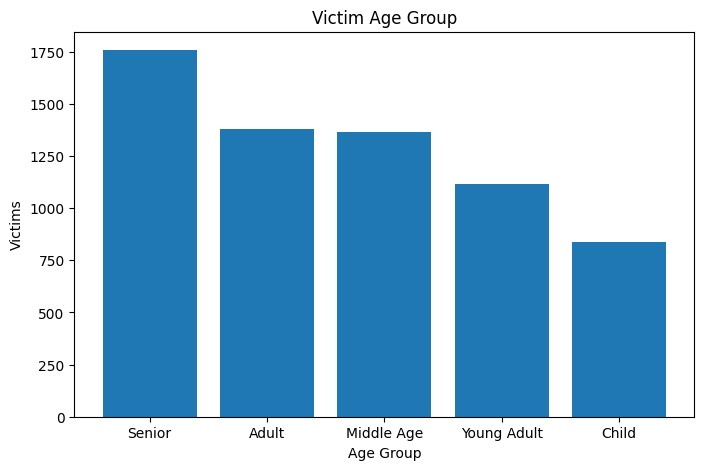

In [14]:
age = df["VictimAgeGroup"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(age.index.astype(str), age.values)

plt.title("Victim Age Group")

plt.xlabel("Age Group")

plt.ylabel("Victims")

plt.show()